<a href="https://colab.research.google.com/github/moniruzzaman01/Ai-ML/blob/main/Data_Processing_and_Logistic_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (2).csv


In [ ]:
df_heart = pd.read_csv('heart.csv')
display(df_heart.head(10))
display(df_heart.dtypes)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


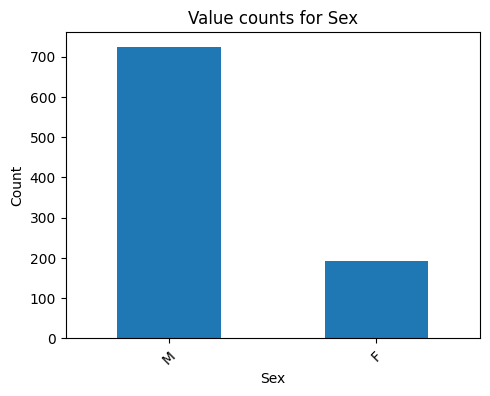

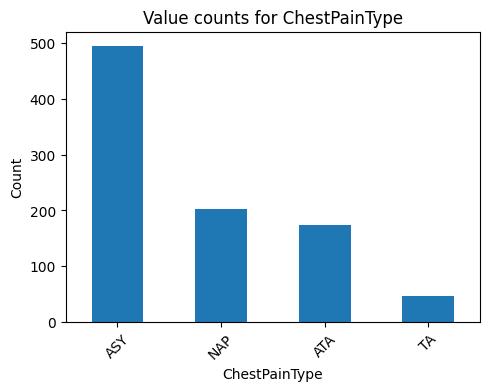

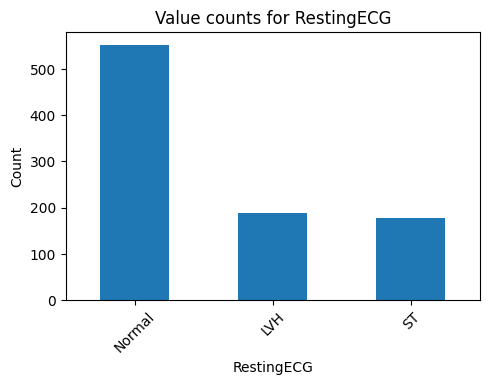

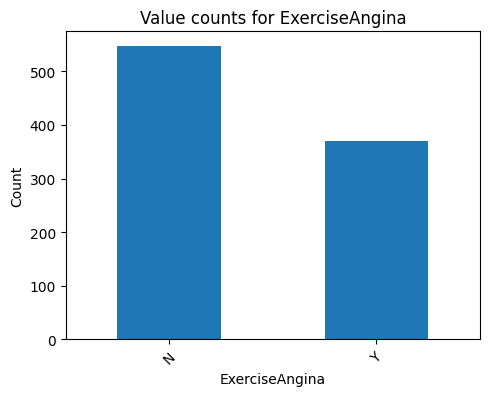

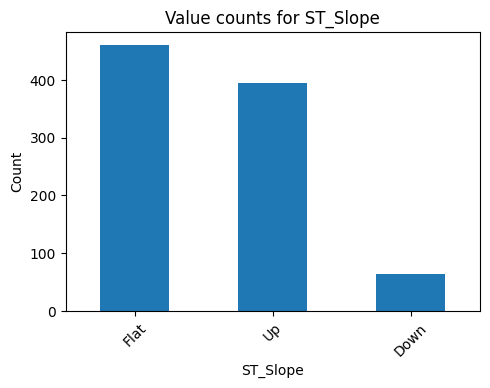

In [ ]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df_heart[c].value_counts().plot(kind='bar')
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.xticks(rotation=45)
  plt.show()

In [ ]:
# Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_heart['Sex'] = le.fit_transform(df_heart['Sex'])
df_heart['ExerciseAngina'] = le.fit_transform(df_heart['ExerciseAngina'])
display(df_heart.head(10))

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
5,39,1,NAP,120,339,0,Normal,170,0,0.0,Up,0
6,45,0,ATA,130,237,0,Normal,170,0,0.0,Up,0
7,54,1,ATA,110,208,0,Normal,142,0,0.0,Up,0
8,37,1,ASY,140,207,0,Normal,130,1,1.5,Flat,1
9,48,0,ATA,120,284,0,Normal,120,0,0.0,Up,0


In [ ]:
# One hot encoding
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df_heart_encoded = pd.get_dummies(df_heart, columns=cat_cols, dtype=int, prefix='CPT')
display(df_heart_encoded.head(10))

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,CPT_ASY,CPT_ATA,CPT_NAP,CPT_TA,CPT_LVH,CPT_Normal,CPT_ST,CPT_Down,CPT_Flat,CPT_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Column selection for train and text and target column
target_col = 'HeartDisease'
X = df_heart_encoded.drop(columns=[target_col])
y = df_heart_encoded[target_col]

# split data into test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# scaling data using standard scaler
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

# transform data info dataframe
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
X_test_std_df = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)

print("Diplay transformed data using standard scaling")
display(X_train_std_df.head(5))
display(X_test_std_df.head(5))

# min max scaler
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

# transform data info dataframe
X_train_mm_df = pd.DataFrame(X_train_mm, columns=X_train.columns, index=X_train.index)
X_test_mm_df = pd.DataFrame(X_test_mm, columns=X_test.columns, index=X_test.index)

print("Display transformed data using min max scaling")
display(X_train_mm_df.head(5))
display(X_test_mm_df.head(5))


Diplay transformed data using standard scaling


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,CPT_ASY,CPT_ATA,CPT_NAP,CPT_TA,CPT_LVH,CPT_Normal,CPT_ST,CPT_Down,CPT_Flat,CPT_Up
155,0.239292,0.537019,1.183802,1.307314,1.877849,0.551672,1.182037,1.900458,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
362,0.239292,0.537019,1.183802,-1.878000,-0.532524,-1.486343,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
869,0.558968,0.537019,0.913811,0.096522,1.877849,0.831400,-0.845997,0.624033,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
101,-0.293501,0.537019,-0.166155,-0.210833,-0.532524,-1.446382,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
199,0.345851,-1.862131,-0.166155,0.990645,-0.532524,-1.526304,-0.845997,0.076994,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,CPT_ASY,CPT_ATA,CPT_NAP,CPT_TA,CPT_LVH,CPT_Normal,CPT_ST,CPT_Down,CPT_Flat,CPT_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999


Display transformed data using min max scaling


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,CPT_ASY,CPT_ATA,CPT_NAP,CPT_TA,CPT_LVH,CPT_Normal,CPT_ST,CPT_Down,CPT_Flat,CPT_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,CPT_ASY,CPT_ATA,CPT_NAP,CPT_TA,CPT_LVH,CPT_Normal,CPT_ST,CPT_Down,CPT_Flat,CPT_Up
668,0.708333,0.0,0.700,0.323383,0.0,0.899225,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
30,0.500000,1.0,0.725,0.859038,0.0,0.519380,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
377,0.750000,1.0,0.800,0.000000,1.0,0.457364,0.0,0.431818,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
535,0.562500,1.0,0.650,0.000000,0.0,0.457364,1.0,0.409091,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
807,0.520833,1.0,0.540,0.512438,0.0,0.720930,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


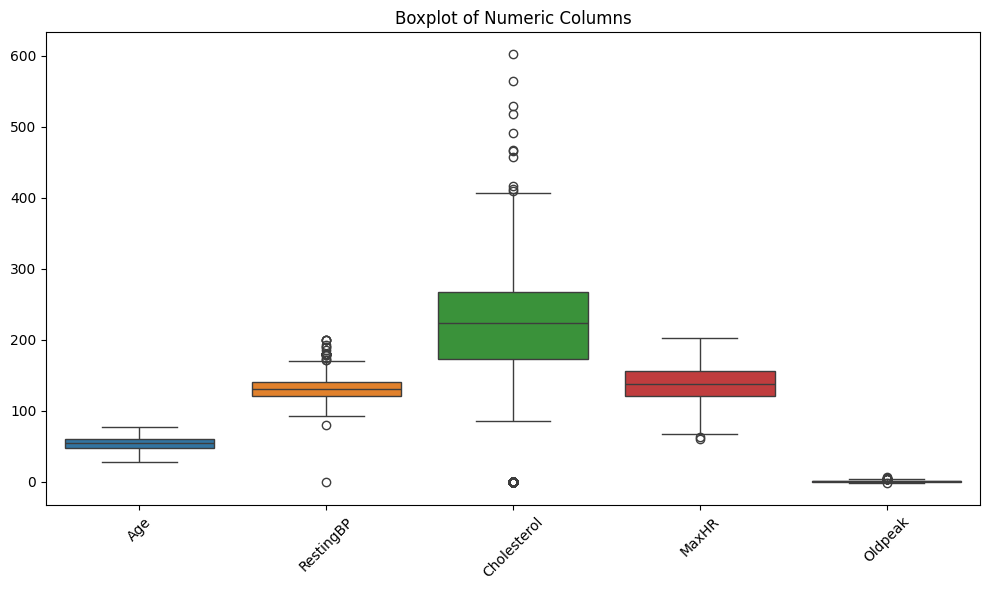

In [ ]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
plt.figure(figsize=(10,6))
sns.boxplot(data=df_heart_encoded[numeric_cols])
plt.title("Boxplot of Numeric Columns")
plt.xticks(rotation=45)
plt.tight_layout()


In [ ]:
col = 'Cholesterol' # ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
Q1 = df_heart_encoded[col].quantile(.25)
Q3 = df_heart_encoded[col].quantile(.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_heart_encoded[(df_heart_encoded[col]<lower_bound) | (df_heart_encoded[col]>upper_bound)]
print(f"Number of detected outliers {col}: ", len(outliers))

Number of detected outliers Cholesterol:  183


In [ ]:
# Remove outliers
df_without_outliers = df_heart_encoded[(df_heart_encoded[col]>=lower_bound) & (df_heart_encoded[col]<=upper_bound)]
print(len(df_without_outliers))

# cap outliers
df_capped = df_heart_encoded.copy()
df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)

# log transform to handle outliers
df_log = df_heart_encoded.copy()
df_log[col + '_log'] = np.log(df_log[col]+1)

display(df_log.head(10))

735


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,CPT_ASY,CPT_ATA,CPT_NAP,CPT_TA,CPT_LVH,CPT_Normal,CPT_ST,CPT_Down,CPT_Flat,CPT_Up,Cholesterol_log
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1,5.669881
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0,5.198497
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1,5.648974
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0,5.370638
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1,5.278115
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1,5.828946
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1,5.472271
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1,5.342334
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0,5.337538
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1,5.652489


# Feature TRansformations

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_cols = ['Age','MaxHR']
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df_heart_encoded[poly_cols])
poly_feature_names = poly.get_feature_names_out(poly_cols)

print(poly_feature_names)
print(poly_features.shape)

['Age' 'MaxHR' 'Age^2' 'Age MaxHR' 'MaxHR^2']
(918, 5)


In [ ]:
# Binning feature
df_heart_encoded['Age_bin'] = pd.cut(
    df_heart_encoded['Age'],
    bins=[0,30,50,100],
    labels=['Young', 'Middle-aged', 'Senior']
)

print(df_heart_encoded[['Age','Age_bin']].head(20))

    Age      Age_bin
0    40  Middle-aged
1    49  Middle-aged
2    37  Middle-aged
3    48  Middle-aged
4    54       Senior
5    39  Middle-aged
6    45  Middle-aged
7    54       Senior
8    37  Middle-aged
9    48  Middle-aged
10   37  Middle-aged
11   58       Senior
12   39  Middle-aged
13   49  Middle-aged
14   42  Middle-aged
15   54       Senior
16   38  Middle-aged
17   43  Middle-aged
18   60       Senior
19   36  Middle-aged


# Domain Driven Feature

In [ ]:
def bp_risk(bp):
  if bp<120:
    return "Normal"
  elif bp<140:
    return "Elevated"
  else:
    return "High"

def oldpeak_risk(op):
  if op==0:
    return "No Stress"
  elif op<2:
    return "Moderate Stress"
  else:
    return "High Stress"

df_heart_encoded['RBP_risk'] = df_heart_encoded['RestingBP'].apply(bp_risk)
df_heart_encoded['Oldpeak_risk'] = df_heart_encoded['Oldpeak'].apply(oldpeak_risk)
df_heart_encoded[["RestingBP", "RBP_risk", "Oldpeak","Oldpeak_risk"]]

,RestingBP,RBP_risk,Oldpeak,Oldpeak_risk
0,140,High,0.0,No Stress
1,160,High,1.0,Moderate Stress
2,130,Elevated,0.0,No Stress
3,138,Elevated,1.5,Moderate Stress
4,150,High,0.0,No Stress
...,...,...,...,...
913,110,Normal,1.2,Moderate Stress
914,144,High,3.4,High Stress
915,130,Elevated,1.2,Moderate Stress
916,130,Elevated,0.0,No Stress


# Creating Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ExerciseAngina", "ChestPainType", "RestingECG", "ST_Slope"]

# numerical pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# categorical pipeline
categorical_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first'))
])

# combine both pipeline
preprocess = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Full pipeline
clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

In [ ]:
X = df_heart.drop(columns=[target_col])
y = df_heart[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

clf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}")

Accuracy: 0.8434782608695652
